## Trabajo Práctico 3
- Tomás Koller
- Alan Gurmendi

### Ejercicio 1: Obtener una detección del logo en cada imagen sin falsos positivos

#### Importamos librerías y creamos rutas de imagenes y template

In [20]:
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt

In [21]:
base_path  = '/home/v-tkoller/EspecializacionIA/vision_computadora_I/Material_TPs/TP3'
template_path = f"{base_path}/template/pattern.png"
images_path = f"{base_path}/images"

In [22]:
images_path

'/home/v-tkoller/EspecializacionIA/vision_computadora_I/Material_TPs/TP3/images'

#### Enlistamos las imagenes a procesar

In [23]:
images_names = ['coca_logo_1.png','coca_logo_2.png','coca_retro_1.png','coca_retro_2.png','logo_1.png','COCA-COLA-LOGO.jpg']

#### Función para carga de imágenes, escalamiento y muestra

In [24]:
def plot_base(template_path, images_path, image, scale, template):
    # Cargamos la imagen a procesar
    img_logo_2 = cv.imread(f"{images_path}/{image}")

    img_rgb = cv.cvtColor(img_logo_2, cv.COLOR_BGR2RGB)
    img_gray = cv.cvtColor(img_logo_2, cv.COLOR_BGR2GRAY)

    # >>> Escalar SOLO en función del template (no de la imagen)
    new_width  = max(1, int(template.shape[1] * scale))
    new_height = max(1, int(template.shape[0] * scale))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_CUBIC
    template_nivel_1 = cv.resize(template, (new_width, new_height), interpolation=interp)
    # <<<

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_nivel_1, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(img_rgb)

In [25]:
def template_format(image,template):
    inverted_template = 255 - template
    if image == 'coca_logo_1.png':
        return 0.4, inverted_template
    elif image == 'coca_logo_2.png':
        return 0.45, inverted_template
    elif image == 'coca_retro_1.png':
        return 1.2, template
    elif image == 'coca_retro_2.png':
        return 0.4, inverted_template
    elif image == 'logo_1.png':
        return 0.7, inverted_template
    elif image == 'COCA-COLA-LOGO.jpg':
        return 3, inverted_template
    elif image == 'coca_multi.png':
        return 0.23, inverted_template

#### Definimos y aplicamos método de Template matching

max_val: 11126166.0, max_loc(33, 200)


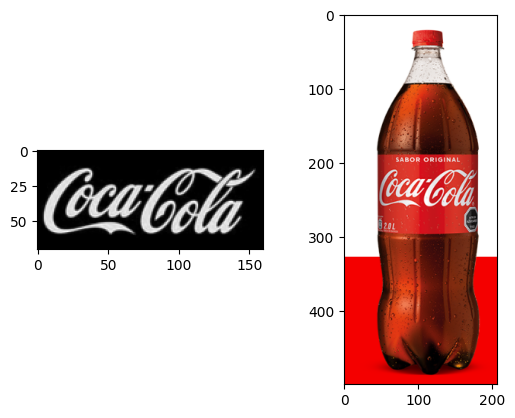

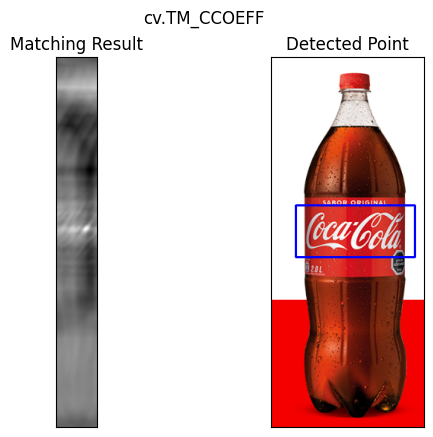

max_val: 8588745.0, max_loc(24, 120)


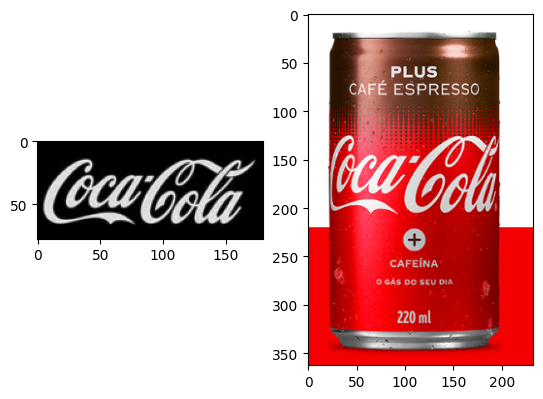

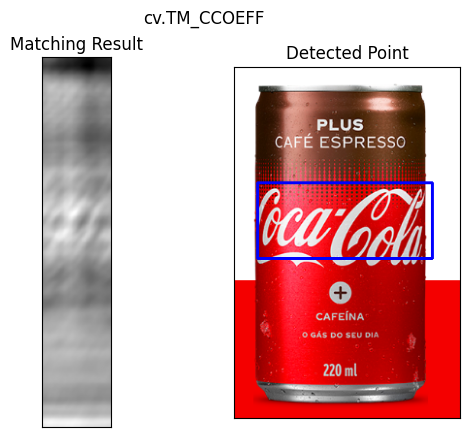

max_val: 185822864.0, max_loc(113, 80)


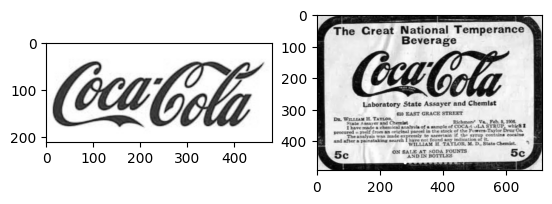

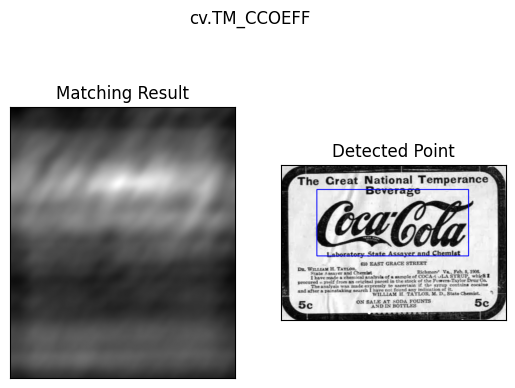

max_val: 19048766.0, max_loc(58, 181)


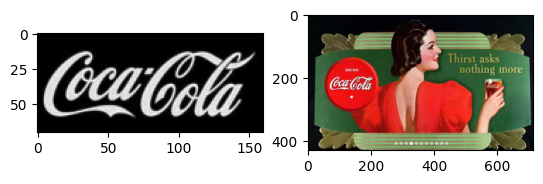

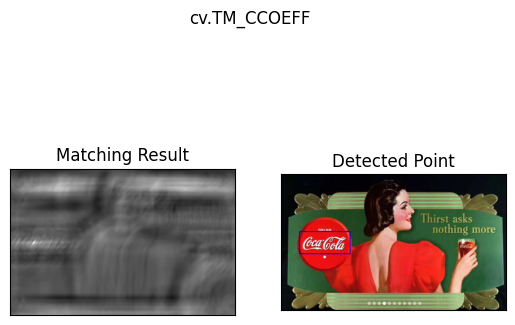

max_val: 44389396.0, max_loc(201, 193)


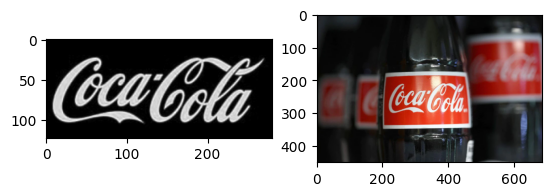

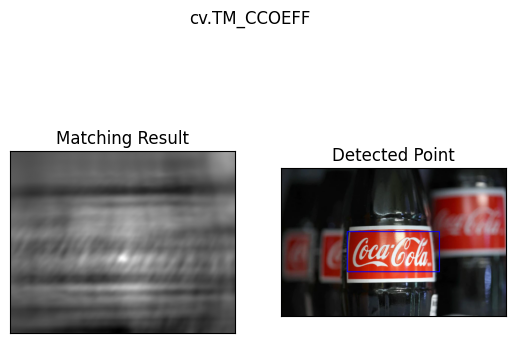

max_val: 1505007616.0, max_loc(77, 399)


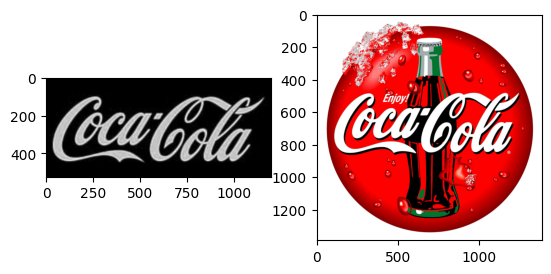

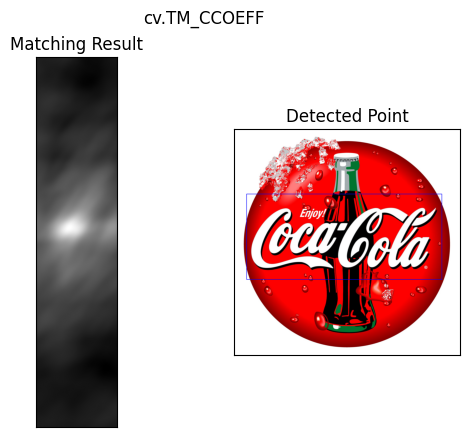

In [26]:
meth = 'cv.TM_CCOEFF'

for image in images_names:

    img = cv.imread(f"{images_path}/{image}")

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    base_template = cv.imread(template_path, 0)
    scale, template = template_format(image, base_template)

    plot_base(template_path, images_path, image, scale, template)

    # >>> Escalar SOLO en función del template (no de la imagen)
    new_width  = max(1, int(template.shape[1] * scale))
    new_height = max(1, int(template.shape[0] * scale))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_CUBIC
    template_nivel_1 = cv.resize(template, (new_width, new_height), interpolation=interp)
    # <<<

    w, h = template_nivel_1.shape[::-1]

    img_salida = img_rgb.copy()
    
    method = eval(meth)
    
    # Aplicamos la coincidencia de patrones
    res = cv.matchTemplate(img_gray, template_nivel_1, method)
    
    # Encontramos los valores máximos y mínimos
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    print(f"max_val: {max_val}, max_loc{max_loc}")
    
    # Si el método es TM_SQDIFF o TM_SQDIFF_NORMED, tomamos el mínimo
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    
    # Marcamos el lugar donde lo haya encontrado
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv.rectangle(img_salida, top_left, bottom_right, (0, 0, 255), 2)

    # Graficamos el procesamiento y la salida
    plt.figure()
    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_salida)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)
    plt.show()


### Ejercicio 2: Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1

#### Definimos y aplicamos método de Template matching

Matches encontrados: 87


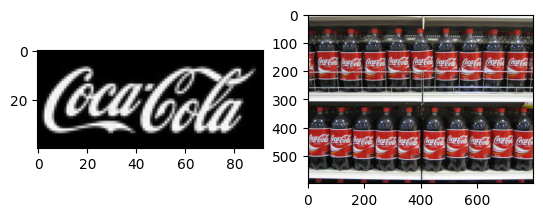

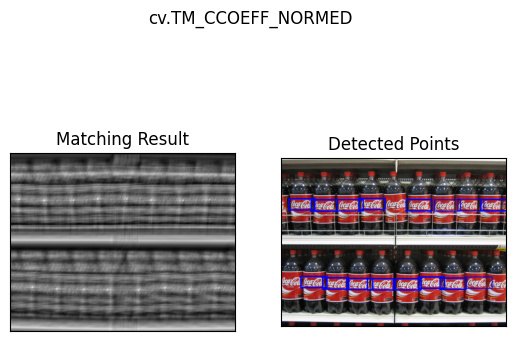

In [27]:
meth = 'cv.TM_CCOEFF_NORMED'

image = 'coca_multi.png'


img = cv.imread(f"{images_path}/{image}")

img_rgb= cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray= cv.cvtColor(img, cv.COLOR_BGR2GRAY)

base_template = cv.imread(template_path,0)
scale, template = template_format(image,base_template)

scale = 0.23

plot_base(template_path, images_path,image,scale,template)

#h_img, w_img = img_gray.shape
#new_width = int(w_img * scale)
#new_height = int(template.shape[0] * (new_width / template.shape[1]))
#template_nivel_1 = cv.resize(template, (new_width, new_height), interpolation=cv.INTER_AREA)

new_width  = max(1, int(template.shape[1] * scale))
new_height = max(1, int(template.shape[0] * scale))
interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_CUBIC
template_nivel_1 = cv.resize(template, (new_width, new_height), interpolation=interp)

w, h = template_nivel_1.shape[::-1]

img = img_rgb.copy()
    
method = eval(meth)
    
# Aplicamos la coincidencia de patrones
#--------------------------------------
# Coincidencia de patrones
res = cv.matchTemplate(img_gray, template_nivel_1, method)

# Umbral para considerar un match como válido (ajustar según resultados)
#threshold = 0.75 * res.max()

threshold = 0.46

# Encuentra posiciones donde el score >= umbral
loc = np.where(res >= threshold)

print(f"Matches encontrados: {len(loc[0])}")

for pt in zip(*loc[::-1]):  # invierte para (x, y)
    bottom_right = (pt[0] + w, pt[1] + h)
    cv.rectangle(img, pt, bottom_right, (0, 0, 255), 2)

# Graficar
plt.figure()
plt.subplot(121), plt.imshow(res, cmap='gray')
plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(img)
plt.title('Detected Points'), plt.xticks([]), plt.yticks([])

plt.suptitle(meth)
plt.show()
    


### Interpretación de los resultados
- El método de template matching por correlación normalizada responde bien cuando la imagen de entrada contiene el patrón con alta similitud en escala, orientación e iluminación respecto a la plantilla.
- En imágenes con buena coincidencia, los valores de correlación se acercan a 1, indicando una correspondencia clara entre el patrón y una región de la imagen.
- Cuando no existe coincidencia o el patrón difiere significativamente, la correlación disminuye, y el umbral definido evita falsos positivos.





### Posibles causas de errores
- Escala y orientación: El método no es invariante a cambios de tamaño o rotación, lo que puede provocar falsos negativos.
- Variaciones de iluminación y contraste: Cambios en la iluminación o color pueden reducir el valor de correlación, aunque la forma del logotipo sea la misma.
- Ruido y oclusiones: Objetos que tapan parcial o totalmente el logotipo afectan la detección.